In [181]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from pathlib import Path


# Finish line should be drawn in Green

In [182]:
image_path = Path('/home/aj/workspaces/boticar-f1tenth-car-ros2/src/boticar_bringup/maps/bauhaus_26-4-2025_sim_4-5-2025-improved-odom-refined/map.pgm')
output_path = Path('.').parent / '../output'  
output_path.mkdir(exist_ok=True)

print(f"Processing {image_path}...")

Processing /home/aj/workspaces/boticar-f1tenth-car-ros2/src/boticar_bringup/maps/bauhaus_26-4-2025_sim_4-5-2025-improved-odom-refined/map.pgm...


In [183]:
map_folder = image_path.parent

In [184]:
# log content
map_config_file = map_folder / 'map.yaml'
with open(map_config_file, 'r') as f:
    log_content = f.readlines()
log_content = [line.strip() for line in log_content if line.strip()]
log_content

['image: map.pgm',
 'mode: trinary',
 'resolution: 0.05',
 'origin: [-5.34, -7.49, 0]',
 'negate: 0',
 'occupied_thresh: 0.65',
 'free_thresh: 0.25']

In [185]:
# List the directory contents recursively
def list_files_recursively(directory):
    for path in directory.rglob('*'):
        if path.is_file():
            print(path)
list_files_recursively(map_folder)

/home/aj/workspaces/boticar-f1tenth-car-ros2/src/boticar_bringup/maps/bauhaus_26-4-2025_sim_4-5-2025-improved-odom-refined/map.pgm
/home/aj/workspaces/boticar-f1tenth-car-ros2/src/boticar_bringup/maps/bauhaus_26-4-2025_sim_4-5-2025-improved-odom-refined/map.data
/home/aj/workspaces/boticar-f1tenth-car-ros2/src/boticar_bringup/maps/bauhaus_26-4-2025_sim_4-5-2025-improved-odom-refined/map.yaml
/home/aj/workspaces/boticar-f1tenth-car-ros2/src/boticar_bringup/maps/bauhaus_26-4-2025_sim_4-5-2025-improved-odom-refined/racing_line_edit.xcf
/home/aj/workspaces/boticar-f1tenth-car-ros2/src/boticar_bringup/maps/bauhaus_26-4-2025_sim_4-5-2025-improved-odom-refined/map.posegraph
/home/aj/workspaces/boticar-f1tenth-car-ros2/src/boticar_bringup/maps/bauhaus_26-4-2025_sim_4-5-2025-improved-odom-refined/racing_line_1.png
/home/aj/workspaces/boticar-f1tenth-car-ros2/src/boticar_bringup/maps/bauhaus_26-4-2025_sim_4-5-2025-improved-odom-refined/track.png
/home/aj/workspaces/boticar-f1tenth-car-ros2/src/b

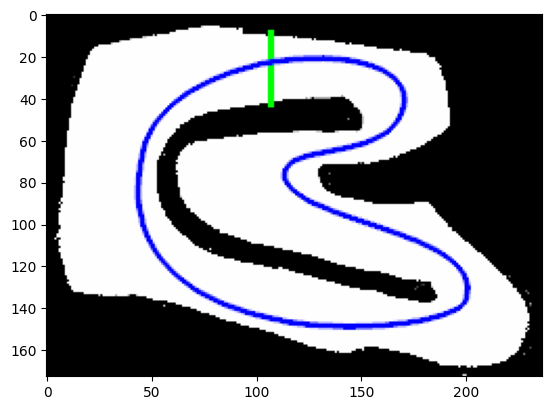

In [186]:
# Load racing_lines/map_race_line_drawn.png
track_png_path = map_folder / 'racing_lines' / '1' /'racing_line.png'
# racing_lines = cv2.imread(str(racing_lines_path), cv2.COLOR_RGB2BGR)
racing_lines = cv2.imread(str(track_png_path), cv2.COLOR_BGR2RGB)
# racing_lines = cv2.imread(str(racing_lines_path), cv2.COLOR_BGR2GRAY)
# Show the image
plt.imshow(racing_lines)

In [187]:
def mask_green_regions(image):
    # Convert the image from BGR to HSV color space
    hsv_image = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    
    # Define the range for green color in HSV.
    # These values can be tuned to detect different shades of green.
    # Hue range for green is typically between 35 and 85 in OpenCV's 0-180 scale.
    lower_green = np.array([35, 50, 50])   # Lower bound for green
    upper_green = np.array([85, 255, 255])  # Upper bound for green
    
    # Create a mask for the green color range
    green_mask = cv2.inRange(hsv_image, lower_green, upper_green)
    
    # Apply the mask to the original image using a bitwise AND operation
    green_only_image = cv2.bitwise_and(image, image, mask=green_mask)
    
    return green_only_image

In [188]:
start_finish_line = mask_green_regions(racing_lines)


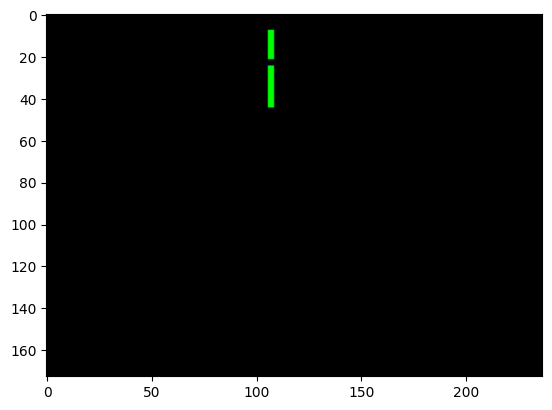

In [189]:
# Show the image
plt.imshow(start_finish_line)

In [190]:
import cv2
import numpy as np
from typing import Tuple

def find_line_endpoints(mask_image: np.ndarray, angle_tolerance_deg: float = 5.0) -> Tuple[Tuple[int, int], Tuple[int, int]]:
    """
    Processes a binary mask image to find the outermost endpoints of a line.
    
    This function handles cases with one solid line or two gapped, collinear line segments.
    """
    # Ensure the input image is single-channel grayscale
    if len(mask_image.shape) == 3:
        mask_image = cv2.cvtColor(mask_image, cv2.COLOR_BGR2GRAY)
    
    # 1. Find contours in the binary mask image
    contours, _ = cv2.findContours(mask_image, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    # 2. Validate that one or two contours (line segments) are found
    if not (1 <= len(contours) <= 2):
        raise ValueError(f"Expected 1 or 2 line segments, but found {len(contours)}. Check the color mask.")

    # 3. Analyze the properties of each line segment
    line_properties = []
    for contour in contours:
        rect = cv2.minAreaRect(contour)
        line_properties.append(rect)

    # 4. If there are two lines, validate that their headings are the same
    if len(contours) == 2:
        angle1 = line_properties[0][2]
        angle2 = line_properties[1][2]
        
        if abs(angle1 - angle2) > 45: 
             if angle1 < -45: angle1 += 90
             if angle2 < -45: angle2 += 90

        angle_diff = abs(angle1 - angle2)

        if angle_diff > angle_tolerance_deg:
            raise ValueError(f"Line segments are not parallel. Angle diff: {angle_diff:.2f}")

    # 5. Get all endpoints from the detected line(s)
    all_endpoints = []
    for rect in line_properties:
        box = cv2.boxPoints(rect)
        max_dist = 0
        p1, p2 = None, None
        for i in range(4):
            for j in range(i + 1, 4):
                dist = np.linalg.norm(box[i] - box[j])
                if dist > max_dist:
                    max_dist = dist
                    p1, p2 = box[i], box[j]
        all_endpoints.extend([p1, p2])

    # 6. Find the two outermost points from all collected endpoints
    # This works for both the 2-point case (one line) and 4-point case (two lines)
    final_p1, final_p2 = None, None
    max_final_dist = 0
    if len(all_endpoints) > 1:
        for i in range(len(all_endpoints)):
            for j in range(i + 1, len(all_endpoints)):
                dist = np.linalg.norm(all_endpoints[i] - all_endpoints[j])
                if dist > max_final_dist:
                    max_final_dist = dist
                    final_p1 = tuple(all_endpoints[i].astype(int))
                    final_p2 = tuple(all_endpoints[j].astype(int))
    else: # Should not happen based on contour check, but as a safe fallback
        return (0,0), (0,0)


    return final_p1, final_p2


In [191]:
start_line_points = find_line_endpoints(start_finish_line)
# racing_line_points.reshape(2, -1)
start_line_points

((np.int64(108), np.int64(44)), (np.int64(106), np.int64(8)))

In [192]:
import cv2
import yaml

def load_yaml(yaml_file: str) -> dict:
    """Load and parse the ROS .yaml file."""
    with open(yaml_file, 'r') as file:
        map_data = yaml.safe_load(file)
    return map_data

def map_image_to_world(points, yaml_file, image_height):
    """
    Map image pixel coordinates to world coordinates using ROS .yaml metadata.
    
    Args:
        points: List of [x, y] pixel coordinates from the image.
        yaml_file: Path to the ROS .yaml file.
        image_height: Height of the original map image in pixels.
    
    Returns:
        List of [x_world, y_world] coordinates in the world frame.
    """
    # Load .yaml file
    map_data = load_yaml(yaml_file)
    resolution = map_data['resolution']  # Meters per pixel
    origin_x = map_data['origin'][0]    # World x-coordinate of bottom-left pixel
    origin_y = map_data['origin'][1]    # World y-coordinate of bottom-left pixel
    
    # Convert pixel coordinates to world coordinates
    world_points = []
    for x_pixel, y_pixel in points:
        # Map x_pixel to world x
        x_world = origin_x + (x_pixel * resolution)
        
        # Map y_pixel to world y (invert y-axis)
        y_world = origin_y + ((image_height - y_pixel) * resolution)
        
        world_points.append([x_world, y_world])
    
    return world_points

In [193]:
len(start_line_points)

2

In [194]:

# Load the original map image to get its dimensions
map_file_path = map_folder /'map.pgm'
map_file_path

PosixPath('/home/aj/workspaces/boticar-f1tenth-car-ros2/src/boticar_bringup/maps/bauhaus_26-4-2025_sim_4-5-2025-improved-odom-refined/map.pgm')

In [195]:

original_map_image = cv2.imread(map_file_path, cv2.IMREAD_GRAYSCALE)  # Path from .yaml
original_map_image

array([[205, 205, 205, ..., 205, 205, 205],
       [205, 205, 205, ..., 205, 205, 205],
       [205, 205, 205, ..., 205, 205, 205],
       ...,
       [205, 205, 205, ..., 205, 205, 205],
       [205, 205, 205, ..., 205, 205, 205],
       [205, 205, 205, ..., 205, 205, 205]], shape=(173, 237), dtype=uint8)

In [196]:


if original_map_image is None:
    raise ValueError("Could not load the original map image")
image_height = original_map_image.shape[0]  # Height in pixels

# Map the points to world coordinates
world_coordinates = np.array(map_image_to_world(start_line_points, map_config_file, image_height))

In [197]:
len(world_coordinates[:, 0]), len(world_coordinates[:, 1])

(2, 2)

In [198]:
csv_file_path_racing_line = output_path / 'racing_line_coordinates.csv'
csv_file_path_racing_line

PosixPath('../output/racing_line_coordinates.csv')

In [199]:
# Create a csv file to save the world coordinates
import pandas as pd

# Add the racing line points to the csv file
df_racing_line = pd.DataFrame()
df_racing_line['x_world'] = world_coordinates[:, 0]
df_racing_line['y_world'] = world_coordinates[:, 1]

df_racing_line.to_csv(csv_file_path_racing_line, index=False)


# Print or use the world coordinates
for x_world, y_world in world_coordinates:
    print(f"World coordinate: ({x_world:.3f}, {y_world:.3f})")


World coordinate: (0.060, -1.040)
World coordinate: (-0.040, 0.760)


Successfully found line endpoints: P1=(np.int64(108), np.int64(44)), P2=(np.int64(106), np.int64(8))


(np.float64(-0.5), np.float64(236.5), np.float64(172.5), np.float64(-0.5))

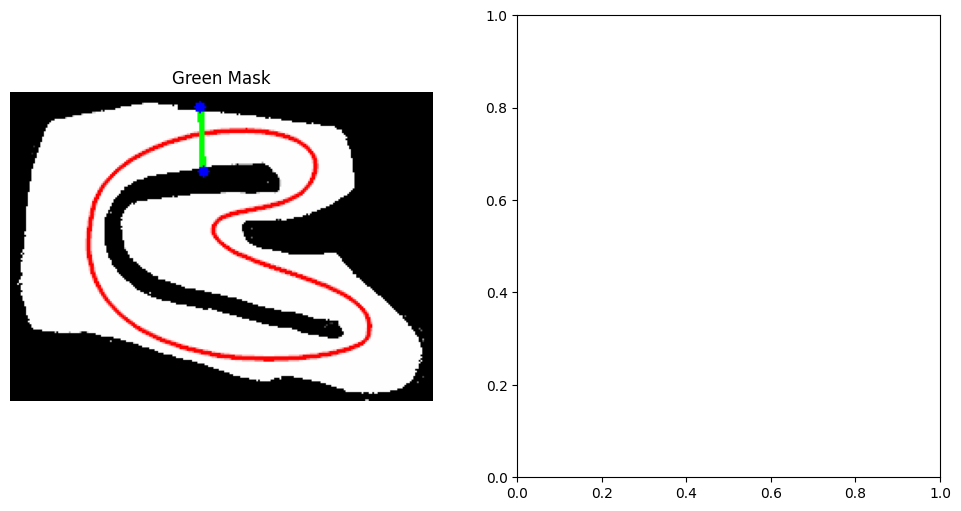

In [200]:
image_for_plotting = racing_lines.copy()

try:
    # --- Part 2: Find the endpoints using the new function ---
    p1, p2 = find_line_endpoints(start_finish_line)
    print(f"Successfully found line endpoints: P1={p1}, P2={p2}")

    # # Visualize the result: Draw the final line over the plotting image
    cv2.line(image_for_plotting, p1, p2, (0, 255, 0), 2) 
    cv2.circle(image_for_plotting, p1, 3, (255, 0, 0), -1) 
    cv2.circle(image_for_plotting, p2, 3, (255, 0, 0), -1) 
    
except ValueError as e:
    print(f"Error: {e}")

# --- Part 3: Plot the results with Matplotlib ---
# Convert the final image from BGR (OpenCV format) to RGB (Matplotlib format)
rgb_image_for_plotting = cv2.cvtColor(image_for_plotting, cv2.COLOR_BGR2RGB)

# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# Plot the green mask
ax1.imshow(rgb_image_for_plotting, cmap='gray')
ax1.set_title('Green Mask')
ax1.axis('off')


In [201]:
# Basic bringing it all together
map_folder = image_path = Path('/home/aj/workspaces/boticar-f1tenth-car-ros2/src/boticar_bringup/maps/bauhaus_26-4-2025_sim_4-5-2025-improved-odom-refined')

In [ ]:

def get_start_finish_line(map_folder: str) -> np.ndarray:
    """
    Get the start and finish line image and its metadata.
    """
    # Define the paths
    map_folder = image_path
    track_png_path = map_folder / 'track.png'
    map_yaml_path = map_folder / 'map.yaml'
    
    # Check if the paths exist
    if not track_png_path.exists():
        raise FileNotFoundError(f"Track image not found at {track_png_path}")
    if not map_yaml_path.exists():
        raise FileNotFoundError(f"Map YAML file not found at {map_yaml_path}")
        
    # Load the start/finish line image
    start_finish_line_image = cv2.imread(str(track_png_path), cv2.COLOR_BGR2RGB)
    # show the image
    if start_finish_line_image is None:
        raise ValueError("Could not load the start/finish line image")
    start_finish_line = mask_green_regions(start_finish_line_image)
    start_line_points = find_line_endpoints(start_finish_line)
    image_height = original_map_image.shape[0]  # Height in pixels
    world_coordinates = np.array(map_image_to_world(start_line_points, map_yaml_path, image_height))
    return world_coordinates



array([[-0.04,  0.76],
       [ 0.06, -1.04]])

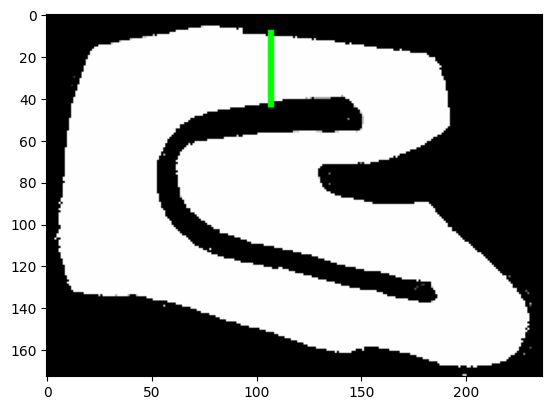

In [207]:
world_coordinates = get_start_finish_line(map_folder)
world_coordinates

In [206]:
# Plot the world coordinates
ax2.plot(world_coordinates[:, 0], world_coordinates[:, 1], 'ro-', markersize=5)
ax2.set_title('Start/Finish Line in World Coordinates')
ax2.set_xlabel('World X (m)')
ax2.set_ylabel('World Y (m)')
ax2.axis('equal')
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>